In [5]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.sparse import eye, diags
from scipy.sparse.linalg import spsolve
import numpy as np

def whittaker_smooth(y, lambda_, d=2):
    """
    Apply Whittaker Smoothing to a signal.
    
    Parameters:
    - y: numpy array, the signal to smooth
    - lambda_: float, the smoothness parameter (higher = smoother)
    - d: int, the order of differences to penalize (default is 2 for second-order)

    Returns:
    - smoothed_y: numpy array, the smoothed signal
    """
    m = len(y)
    
    # Identity matrix
    E = eye(m, format='csc')

    # Second difference matrix
    D = diags([1, -2, 1], [0, 1, 2], shape=(m - d, m), format='csc')

    # Construct the system matrix
    W = E + lambda_ * (D.T @ D)

    # Solve for the smoothed values
    smoothed_y = spsolve(W, y)

    return smoothed_y


In [6]:


file_path = "Book1.xlsx"

data = pd.ExcelFile(file_path)

# print(data.sheet_names)  # Print available sheet names
# print(cm_4.columns)
# print(cm_8.columns)
# print(cm_16.columns)

cm_1 = pd.read_excel(data, "Film_1res").dropna()
cm_2 = pd.read_excel(data, "Film_2res").dropna()
cm_4 = pd.read_excel(data, "Film_4res").dropna()
cm_8 = pd.read_excel(data, "Film_8res").dropna()
cm_16 = pd.read_excel(data, "Film_16res").dropna()

plt.figure(figsize=(7,7))

plt.plot(cm_1["wavenumber"], cm_1["absorbance"], label="Raw Data 1cm", color="blue")
plt.plot(cm_2["wavenumber"], cm_2["absorbance"], label="Raw Data 2cm", color="green")
plt.plot(cm_4["wavenumber"], cm_4["absorbance"], label="Raw Data 4cm", color="purple")
plt.plot(cm_8["wavenumber"], cm_8["absorbance"], label="Raw Data 8cm", color="orange")
plt.plot(cm_16["wavenumber"], cm_16["absorbance"], label="Raw Data 16cm", color="cyan")



# print(cm_1["absorbance"])

w = 7
p = 3
cm_1["absorbance_smoothed"] = savgol_filter(cm_1["absorbance"], w, polyorder = p, )
plt.plot(cm_1["wavenumber"], cm_1["absorbance_smoothed"], label="Raw Data 1cm smoothed", color="red")

wavenumbers = cm_1["wavenumber"].values  # X-axis


absorbance = cm_1["absorbance_smoothed"].values 

# Add labels and title
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title("FTIR Spectrum")
plt.legend()
plt.grid(True)

plt.gca().invert_xaxis()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Book1.xlsx'

The part after this is to calculate the areas I commented the area computation code for the sake of efficiency and to put them into a dictionary. Then a heat map with the RMSE to see the correlatio of the different areas I was interested in that but there is not much computations in it 

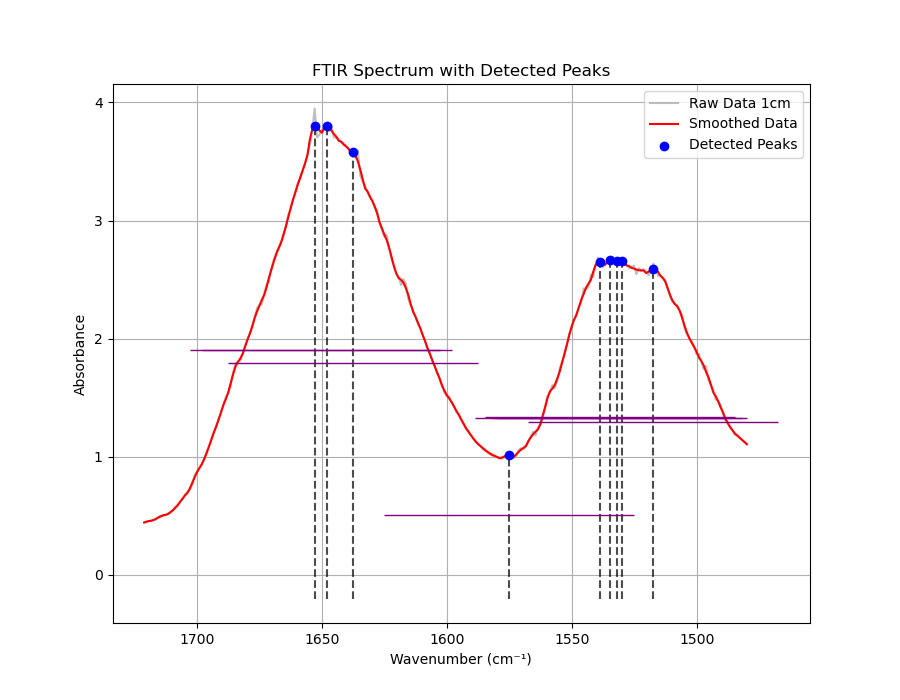

In [ ]:
from scipy.signal import find_peaks

# Define exclusion ranges
exclude_ranges = [(771,1000),(1550, 1620), (3000,3200),(1670, 1720),(1747,2835),(3500,5000)]

peaks, _ = find_peaks(cm_1["absorbance_smoothed"], height=0, prominence=0.0, width=0)


peak_wavenumbers = cm_1["wavenumber"].iloc[peaks].values
peak_absorbance = cm_1["absorbance_smoothed"].iloc[peaks].values






# # Filter peaks based on wavenumber
filtered_indices = [i for i, wn in zip(peaks, peak_wavenumbers) if not any(lower <= wn <= upper for lower, upper in exclude_ranges)]

# peaks = np.array(filtered_indices)
peak_wavenumbers = cm_1["wavenumber"].iloc[peaks].values
peak_absorbance = cm_1["absorbance_smoothed"].iloc[peaks].values
# Update the original peaks array with filtered indices


half_absorbance = peak_absorbance / 2
# Plot Original & Smoothed Data
plt.figure(figsize=(9, 7))
plt.plot(cm_1["wavenumber"], cm_1["absorbance"], label="Raw Data 1cm", color="gray", alpha=0.5)
plt.plot(cm_1["wavenumber"], cm_1["absorbance_smoothed"], label="Smoothed Data", color="red")

plt.vlines(peak_wavenumbers, ymin= - 0.2, ymax=peak_absorbance, color='black', linestyle='dashed', alpha=0.7)

# Draw horizontal lines at half absorbance
for x, y_half in zip(peak_wavenumbers, half_absorbance):
    plt.hlines(y_half, xmin=x-50, xmax=x+50, color='purple', linewidth=1)  # Adjust the range (x-5, x+5) for better visualization

# Mark Detected Peaks
plt.scatter(cm_1["wavenumber"].iloc[peaks], cm_1["absorbance_smoothed"].iloc[peaks], 
            color='blue', label="Detected Peaks", zorder=3)

# Add labels and title
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title("FTIR Spectrum with Detected Peaks")
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()





In [ ]:
print(peak_wavenumbers )
print(peak_absorbance  )
print(peaks)

[1517.626657 1530.106657 1532.026657 1534.906657 1538.746657 1575.226657
 1637.626657 1648.186657 1652.986657]
[2.594279   2.65658205 2.6578951  2.67003219 2.65083729 1.01391795
 3.58149352 3.80157148 3.80510048]
[ 39  52  54  57  61  99 164 175 180]


Optimised (height, σ, γ) per peak:
[[2.10956293e+00 2.99694907e+01 1.00000000e-06]
 [7.95389658e-01 1.60682881e+01 1.00000000e-06]
 [1.36185125e+00 3.88882078e+01 1.00000000e-06]
 [2.41319264e+00 1.65179241e+01 1.88207790e+01]]
height  sampled_max  %diff
   2.110      2.110    0.00%
   0.795      0.795    0.00%
   1.362      1.362    0.00%
   2.413      2.413    0.00%


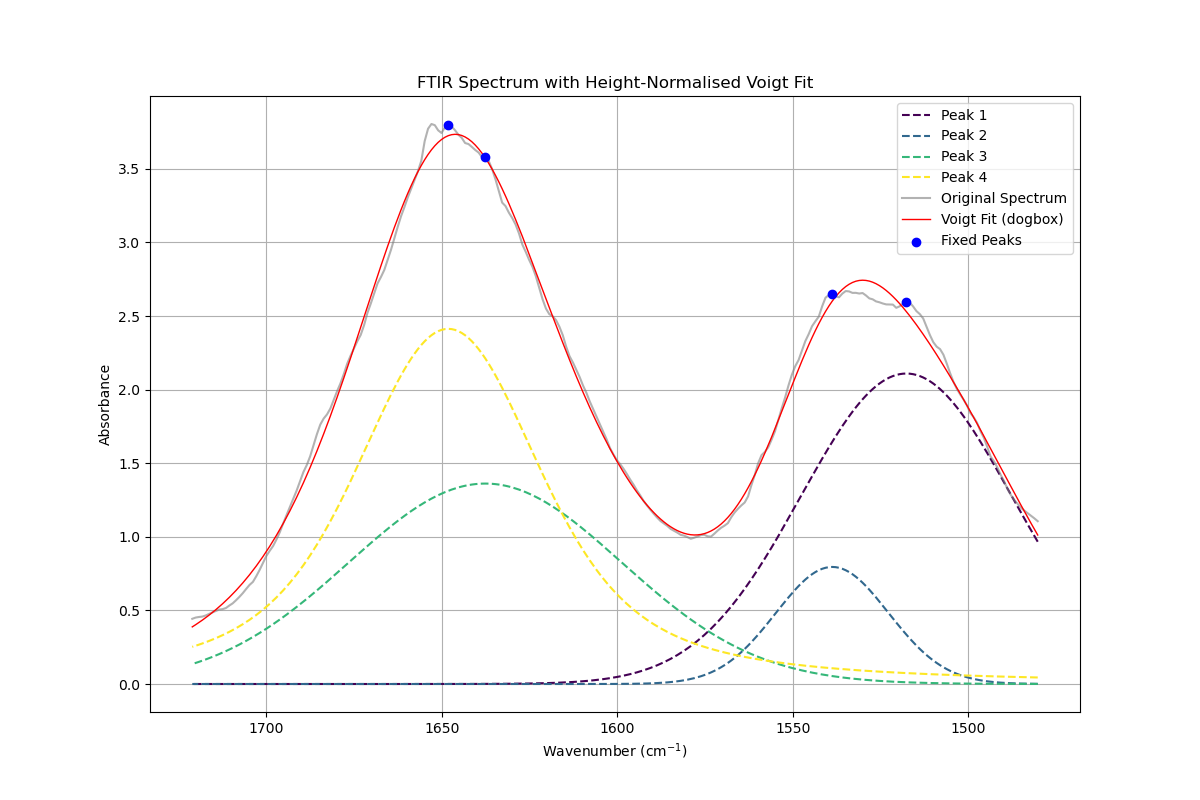

In [ ]:
from scipy.special import wofz
from scipy.optimize import least_squares
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# 1 ─ Height-normalised Voigt profile (amplitude = peak height)
# ────────────────────────────────────────────────────────────────
def voigt_profile(x, amplitude, center, sigma, gamma, eps=1e-8):
    """
    Voigt profile normalised so that `amplitude` equals the peak height.
    A tiny `eps` keeps sigma and gamma away from zero.
    """
    sigma_eff = sigma + eps
    gamma_eff = gamma + eps

    z = ((x - center) + 1j * gamma_eff) / (sigma_eff * np.sqrt(2))
    norm = wofz(1j * gamma_eff / (sigma_eff * np.sqrt(2))).real     # value at centre

    return amplitude * (wofz(z).real / norm)

# ────────────────────────────────────────────────────────────────
# 2 ─ Sum of Voigts, residuals, peak detection as before
# ────────────────────────────────────────────────────────────────
def sum_of_voigt(params, x):
    total = np.zeros_like(x)
    num_peaks = len(peak_wavenumbers)

    for i in range(num_peaks):
        A     = params[i*3]
        sigma = params[i*3 + 1]
        gamma = params[i*3 + 2]
        total += voigt_profile(x, A, peak_wavenumbers[i], sigma, gamma)

    return total

def residuals(params, x, y):
    return sum_of_voigt(params, x) - y

# ────────────────────────────────────────────────────────────────
# 3 ─ Peak list (your manual filtering) and initial guesses
# ────────────────────────────────────────────────────────────────
remove_indices = [1,2,3,5,8]
peaks = np.delete(peaks, remove_indices)
peak_wavenumbers = cm_1["wavenumber"].iloc[peaks].values
peak_absorbance  = cm_1["absorbance_smoothed"].iloc[peaks].values

initial_params = []
for amp in peak_absorbance:             # (height, σ, γ)
    initial_params.extend([amp, 10, 10])

# Lower bounds: height ≥ 0, σ & γ ≥ 1·10⁻⁶  (no zeros!)
lb = np.array([0 if i%3==0 else 1e-6 for i in range(len(initial_params))])

# ────────────────────────────────────────────────────────────────
# 4 ─ Non-linear least-squares (dogbox) with safe bounds
# ────────────────────────────────────────────────────────────────
result = least_squares(residuals,
                       initial_params,
                       args=(wavenumbers, absorbance),
                       method="dogbox",
                       bounds=(lb, np.inf))

opt_params = result.x


print("Optimised (height, σ, γ) per peak:")
print(opt_params.reshape(-1, 3))

# ────────────────────────────────────────────────────────────────
# 5 ─ Build fitted curve + individual peaks for plotting
# ────────────────────────────────────────────────────────────────
num_peaks = len(peak_wavenumbers)
individual_peaks = np.zeros((num_peaks, len(wavenumbers)))
fitted_curve     = np.zeros_like(wavenumbers)

for i in range(num_peaks):
    A, sigma, gamma = opt_params[i*3 : (i+1)*3]
    peak = voigt_profile(wavenumbers, A, peak_wavenumbers[i], sigma, gamma)
    individual_peaks[i] = peak
    fitted_curve += peak

# Compare fitted heights to sampled maxima
check = []
for i in range(len(peak_wavenumbers)):
    A, σ, γ = opt_params[i*3:(i+1)*3]
    peak   = voigt_profile(wavenumbers, A, peak_wavenumbers[i], σ, γ)
    check.append([A, peak.max(), abs(A-peak.max())/A*100])

print("height  sampled_max  %diff")
for h, m, d in check:
    print(f"{h:8.3f}   {m:8.3f}   {d:5.2f}%")



# ────────────────────────────────────────────────────────────────
# 6 ─ Plot
# ────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,8))
colors = plt.cm.viridis(np.linspace(0, 1, num_peaks))

for i in range(num_peaks):
    plt.plot(wavenumbers, individual_peaks[i],
             linestyle="dashed", color=colors[i], label=f"Peak {i+1}")

plt.plot(wavenumbers, absorbance,     "gray",  alpha=0.6, label="Original Spectrum")
plt.plot(wavenumbers, fitted_curve,   "red",   lw=1,      label="Voigt Fit (dogbox)")
plt.scatter(peak_wavenumbers, peak_absorbance,
            color="blue", zorder=3,    label="Fixed Peaks")

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.title("FTIR Spectrum with Height-Normalised Voigt Fit")
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()


Model Performance Metrics:
--------------------------
Root Mean Square Error (RMSE): 0.055080
Mean Absolute Error (MAE): 0.044758
R² Score: 0.996342


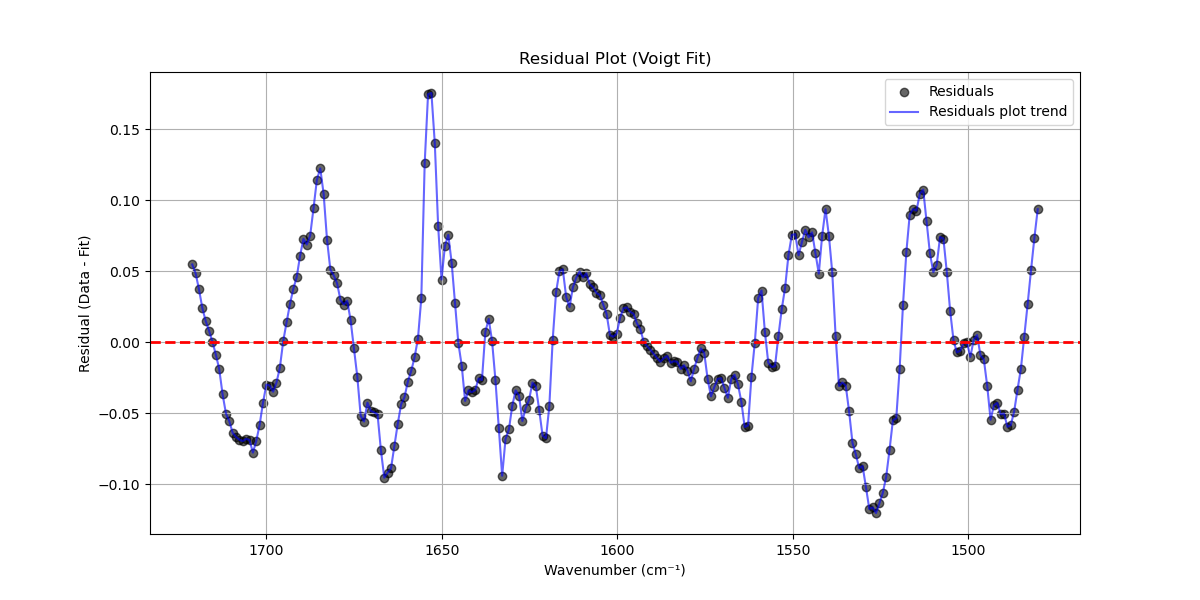

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(absorbance, fitted_curve))
mae = mean_absolute_error(absorbance, fitted_curve)
r2 = r2_score(absorbance, fitted_curve)

# Print results
print(f"Model Performance Metrics:")
print(f"--------------------------")
print(f"Root Mean Square Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R² Score: {r2:.6f}")

# Visualize residuals

residuals = absorbance - fitted_curve

plt.figure(figsize=(12, 6))
plt.scatter(wavenumbers, residuals, color="black", alpha=0.6, label="Residuals")
plt.plot(wavenumbers,residuals,color ="blue", alpha =0.6, label="Residuals plot trend")
plt.axhline(0, color="red", linestyle="dashed", linewidth=2)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Residual (Data - Fit)")
plt.title("Residual Plot (Voigt Fit)")
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()
